# Model 2 — Predicting District-Wise MGNREGA Expenditure
## Step 1: Data Preparation

**Target:** `total_exp_without_liability`  
**Approach:** Temporal split — Train: 2017–2022 | Test: 2023–2024  
**Models:** Linear Regression, Random Forest, XGBoost

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('D:/sem4/DWDM/Datasets/clean_mgnrega_dataset.csv')
print(f'Raw shape: {df.shape}')
print(f'Years: {sorted(df["year"].unique())}')
print(f'Districts: {df["district"].nunique()}')

Raw shape: (262, 19)
Years: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Districts: 28


In [2]:
# Remove rows where district had no activity (zero expenditure = district didn't exist yet)
df_clean = df[df['total_exp_without_liability'] > 0].copy()

print(f'Rows after removing zeros: {df_clean.shape[0]}')
print(f'Zero rows removed: {df.shape[0] - df_clean.shape[0]}')
print(f'\nRows per year (active districts only):')
print(df_clean['year'].value_counts().sort_index())

Rows after removing zeros: 182
Zero rows removed: 80

Rows per year (active districts only):
year
2016    13
2017    13
2018    13
2019    13
2020    13
2021    13
2022    26
2023    26
2024    26
2025    26
Name: count, dtype: int64


In [3]:
# Sort by district and year before shifting
df_clean = df_clean.sort_values(['district', 'year']).reset_index(drop=True)

# Create lag feature: previous year's total expenditure per district
df_clean['prev_year_total_exp'] = (
    df_clean.groupby('district')['total_exp_without_liability'].shift(1)
)

# Check NaN distribution
print(f'NaN in prev_year_total_exp: {df_clean["prev_year_total_exp"].isna().sum()}')
print(f'These are all year 2016 rows (no prior year):')
print(df_clean[df_clean['prev_year_total_exp'].isna()][['district', 'year']].head(10))

NaN in prev_year_total_exp: 26
These are all year 2016 rows (no prior year):
                 district  year
0   ALLURI SITHARAMA RAJU  2022
4              ANAKAPALLI  2022
8               ANANTAPUR  2016
18              ANNAMAYYA  2022
22                BAPATLA  2022
26               CHITTOOR  2016
36          EAST GODAVARI  2016
46                  ELURU  2022
50                 GUNTUR  2016
60               KAKINADA  2022


In [4]:
# Drop 2016 rows (NaN lag values)
df_model = df_clean.dropna(subset=['prev_year_total_exp']).reset_index(drop=True)

print(f'Final dataset shape: {df_model.shape}')
print(f'Years covered: {sorted(df_model["year"].unique())}')
print(f'\nRows per year:')
print(df_model['year'].value_counts().sort_index())

Final dataset shape: (156, 20)
Years covered: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Rows per year:
year
2017    13
2018    13
2019    13
2020    13
2021    13
2022    13
2023    26
2024    26
2025    26
Name: count, dtype: int64


In [5]:
# Features decided based on what is KNOWN before the year starts
# (no leakage from current-year outcomes)

FEATURES = [
    'avg_wage_per_day',          # Policy constant — set by central govt before year starts
    'prev_wage_liability',        # Pending dues carried from previous year — known at year start
    'prev_material_liability',
    'prev_admin_liability',
    'prev_total_liability',
    'works_in_progress',          # Projects carried over from last year — known at year start
    'prev_year_total_exp',        # LAG FEATURE — last year's expenditure per district
]

TARGET = 'total_exp_without_liability'

# Categorical columns to be one-hot encoded
CATEGORICALS = ['year', 'district']
df_model['is_post_reorganization'] = (df_model['year'] >= 2023).astype(int)
FEATURES.append('is_post_reorganization')

print('Features (numerical):')
for f in FEATURES:
    print(f'  - {f}')

print(f'\nCategoricals to encode: {CATEGORICALS}')
print(f'\nTarget: {TARGET}')

Features (numerical):
  - avg_wage_per_day
  - prev_wage_liability
  - prev_material_liability
  - prev_admin_liability
  - prev_total_liability
  - works_in_progress
  - prev_year_total_exp
  - is_post_reorganization

Categoricals to encode: ['year', 'district']

Target: total_exp_without_liability


In [6]:
# Spot check: pick one district and verify lag is correct
check_district = 'ANANTAPUR'
check = df_model[df_model['district'] == check_district][['district', 'year', TARGET, 'prev_year_total_exp']]
print(f'Lag feature verification for {check_district}:')
print(check.to_string(index=False))

print('\n✓ Each row\'s prev_year_total_exp should match the PREVIOUS row\'s total_exp_without_liability')

Lag feature verification for ANANTAPUR:
 district  year  total_exp_without_liability  prev_year_total_exp
ANANTAPUR  2017                     49718.55             42288.22
ANANTAPUR  2018                     64408.67             49718.55
ANANTAPUR  2019                     44573.46             64408.67
ANANTAPUR  2020                     88267.04             44573.46
ANANTAPUR  2021                     65354.65             88267.04
ANANTAPUR  2022                     27225.15             65354.65
ANANTAPUR  2023                     32334.18             27225.15
ANANTAPUR  2024                     35638.92             32334.18
ANANTAPUR  2025                     29745.80             35638.92

✓ Each row's prev_year_total_exp should match the PREVIOUS row's total_exp_without_liability


In [7]:
df_encoded = pd.get_dummies(df_model, columns=['year', 'district'], drop_first=False)

print(f'Shape after encoding: {df_encoded.shape}')
print(f'New dummy columns added: {df_encoded.shape[1] - df_model.shape[1]}')

Shape after encoding: (156, 54)
New dummy columns added: 33


In [8]:
year_dummies     = [c for c in df_encoded.columns if c.startswith('year_')]
district_dummies = [c for c in df_encoded.columns if c.startswith('district_')]
ALL_FEATURES = FEATURES + year_dummies + district_dummies

print(f'Numerical features:     {len(FEATURES)}')
print(f'Year dummy columns:     {len(year_dummies)}')
print(f'District dummy columns: {len(district_dummies)}')
print(f'Total features:         {len(ALL_FEATURES)}')

Numerical features:     8
Year dummy columns:     9
District dummy columns: 26
Total features:         43


In [9]:
# Temporal split — NOT random
# Random split would leak future info into training (data leakage)
# Train on past → Test on recent years → realistic evaluation

TRAIN_YEARS = [2017, 2018, 2019, 2020, 2021, 2022, 2023 ]
TEST_YEARS  = [2024]

train = df_encoded[df_encoded['year'].isin(TRAIN_YEARS)] if 'year' in df_encoded.columns else \
        df_model[df_model['year'].isin(TRAIN_YEARS)].index

# Use original year column from df_model for splitting (before encoding dropped it)
train_idx = df_model[df_model['year'].isin(TRAIN_YEARS)].index
test_idx  = df_model[df_model['year'].isin(TEST_YEARS)].index

X_train = df_encoded.loc[train_idx, ALL_FEATURES]
X_test  = df_encoded.loc[test_idx,  ALL_FEATURES]
y_train = df_encoded.loc[train_idx, TARGET]
y_test  = df_encoded.loc[test_idx,  TARGET]

print(f'X_train: {X_train.shape}  |  y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}   |  y_test:  {y_test.shape}')
print(f'\nTrain years: {TRAIN_YEARS}')
print(f'Test years:  {TEST_YEARS}')

X_train: (104, 43)  |  y_train: (104,)
X_test:  (26, 43)   |  y_test:  (26,)

Train years: [2017, 2018, 2019, 2020, 2021, 2022, 2023]
Test years:  [2024]


Train target stats:
count      104.00
mean     42076.23
std      20065.80
min       4028.30
25%      26397.55
50%      41813.98
75%      53288.85
max      95362.04
Name: total_exp_without_liability, dtype: float64

Test target stats:
count       26.00
mean     28056.09
std      12738.94
min       5297.10
25%      20932.14
50%      26980.93
75%      34864.35
max      57896.38
Name: total_exp_without_liability, dtype: float64


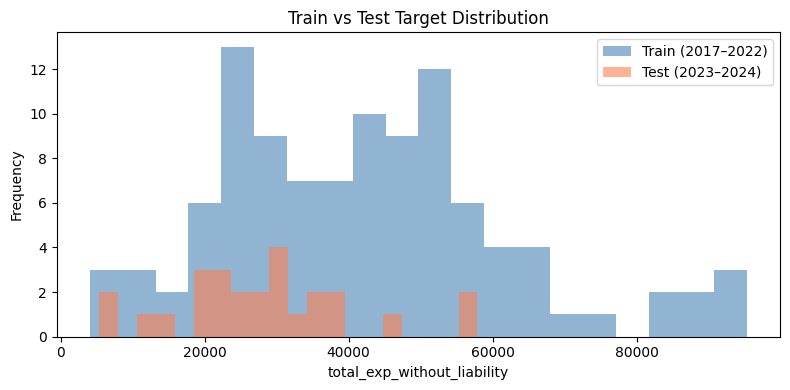

In [10]:
print('Train target stats:')
print(y_train.describe().round(2))

print('\nTest target stats:')
print(y_test.describe().round(2))

# Visual check — are train/test distributions comparable?
plt.figure(figsize=(8, 4))
plt.hist(y_train, bins=20, alpha=0.6, color='steelblue', label='Train (2017–2022)')
plt.hist(y_test,  bins=20, alpha=0.6, color='coral',     label='Test (2023–2024)')
plt.xlabel('total_exp_without_liability')
plt.ylabel('Frequency')
plt.title('Train vs Test Target Distribution')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_squared_error


In [48]:
rf = RandomForestRegressor(
    n_estimators     = 700,
    max_depth        = None,      # was None — most important change
    min_samples_leaf = 1,
    random_state     = 42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

r2_rf   = r2_score(y_test, y_pred_rf)
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf) * 100
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rel_rmse_rf = (rmse_rf / y_test.mean()) * 100

print('Random Forest Results:')
print(f'  R²:            {r2_rf:.4f}')
print(f'  MAPE:          {mape_rf:.2f}%')
print(f'  RMSE:          {rmse_rf:.2f}')
print(f'  Relative RMSE: {rel_rmse_rf:.2f}%')

Random Forest Results:
  R²:            0.8475
  MAPE:          19.19%
  RMSE:          4878.90
  Relative RMSE: 17.39%


In [ ]:
# Manually Tuned parameters
xgb = XGBRegressor(  
    n_estimators    = 500,
    max_depth       = 4,      # shallower trees — less overfit
    learning_rate   = 0.05,
    min_child_weight= 6,      # higher — forces more data per leaf
    subsample       = 0.8,
    colsample_bytree= 0.8, 
    reg_alpha    = 0.05,    # L1 regularization
    reg_lambda      = 2.0,    # L2 regularization
    random_state    = 42,
    verbosity       = 0
    )
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

r2_xgb   = r2_score(y_test, y_pred_xgb)
mape_xgb = mean_absolute_percentage_error(y_test, y_pred_xgb) * 100
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
rel_rmse_xgb = (rmse_xgb / y_test.mean()) * 100

print('XGBoost Results:')
print(f'  R²:            {r2_xgb:.4f}')
print(f'  MAPE:          {mape_xgb:.2f}%')
print(f'  RMSE:          {rmse_xgb:.2f}')
print(f'  Relative RMSE: {rel_rmse_xgb:.2f}%')

XGBoost Results:
  R²:            0.9081
  MAPE:          18.03%
  RMSE:          3786.21
  Relative RMSE: 13.50%


In [49]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'R²':           [r2_rf,       r2_xgb],
    'MAPE (%)':     [mape_rf,     mape_xgb],
    'RMSE':         [rmse_rf,     rmse_xgb],
    'Rel RMSE (%)': [rel_rmse_rf, rel_rmse_xgb]
})
results = results.round(4)
print(results.to_string(index=False))

        Model     R²  MAPE (%)      RMSE  Rel RMSE (%)
Random Forest 0.8475   19.1909 4878.8985       17.3898
      XGBoost 0.9081   18.0290 3786.2098       13.4951


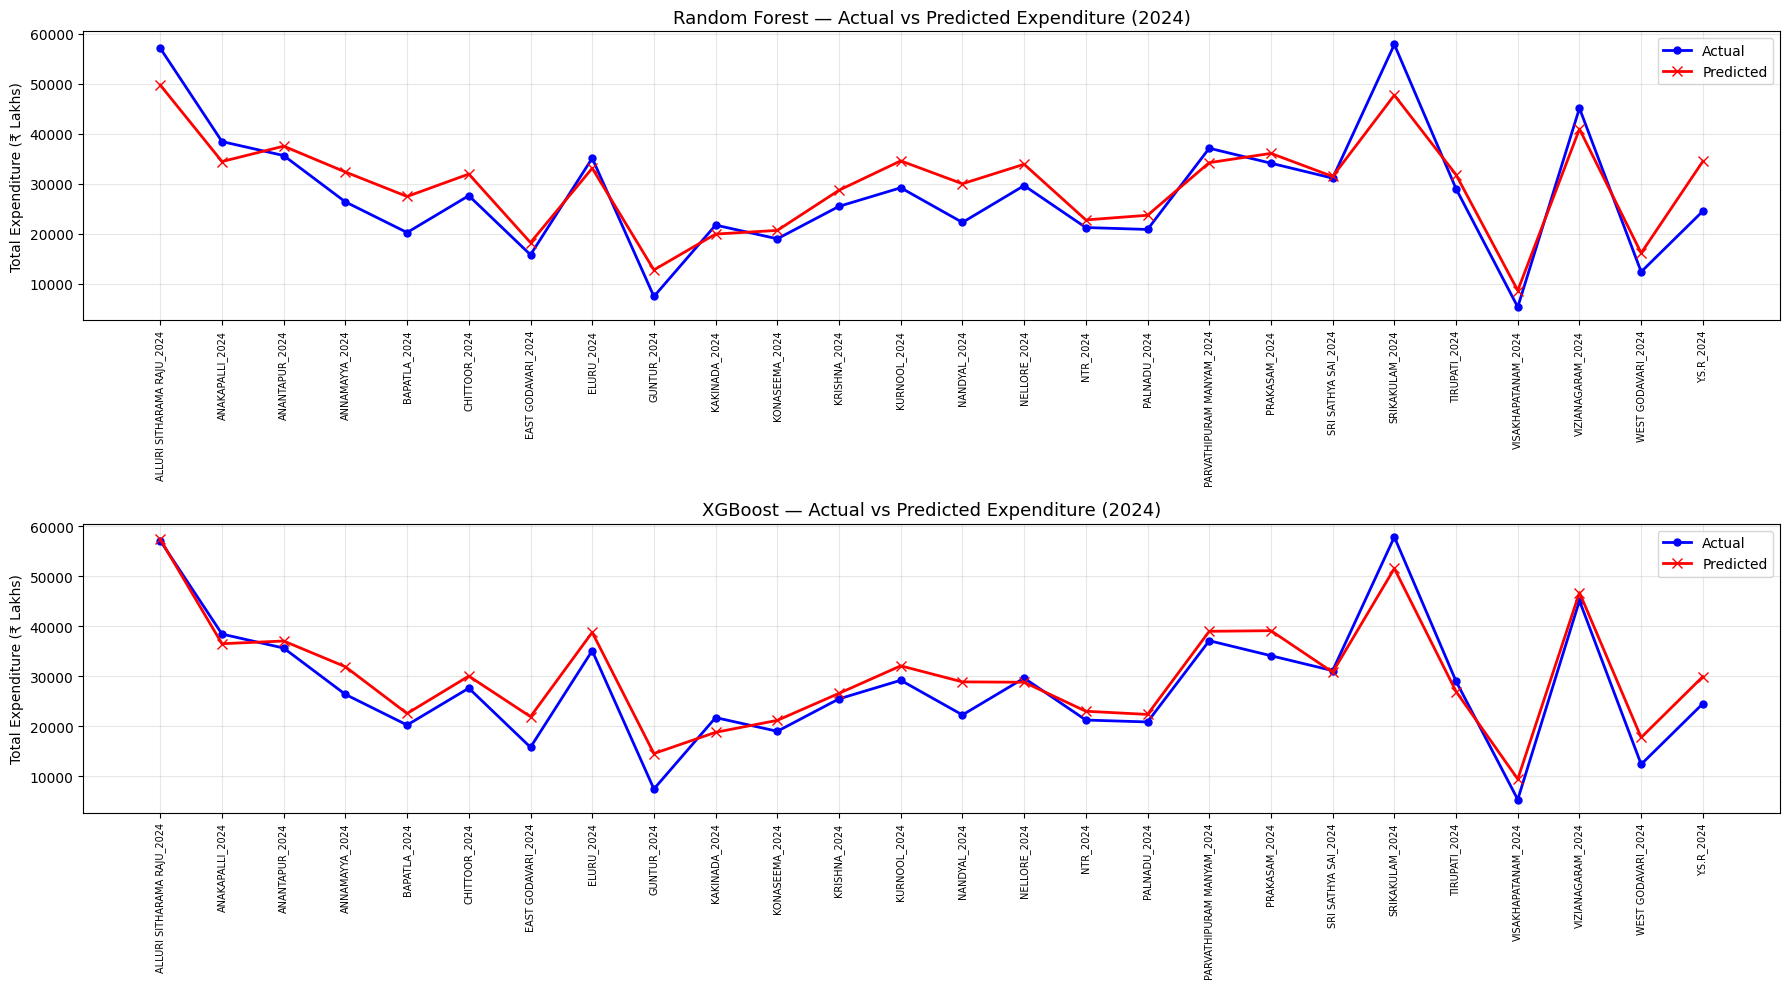

In [50]:
# Get district names for test set
test_districts = df_model.loc[y_test.index, 'district'].values
test_years     = df_model.loc[y_test.index, 'year'].values
labels         = [f"{d}_{y}" for d, y in zip(test_districts, test_years)]

# Sort by district name for clean visualization
sort_idx       = np.argsort(labels)
labels_sorted  = np.array(labels)[sort_idx]
actual_sorted  = np.array(y_test)[sort_idx]
pred_rf_sorted = np.array(y_pred_rf)[sort_idx]
pred_xgb_sorted= np.array(y_pred_xgb)[sort_idx]

fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# --- Random Forest ---
axes[0].plot(labels_sorted, actual_sorted,  'b-o', linewidth=2, markersize=5, label='Actual')
axes[0].plot(labels_sorted, pred_rf_sorted, 'r-x', linewidth=2, markersize=7, label='Predicted')
axes[0].set_title('Random Forest — Actual vs Predicted Expenditure (2024)', fontsize=13)
axes[0].set_ylabel('Total Expenditure (₹ Lakhs)')
axes[0].set_xticks(range(len(labels_sorted)))
axes[0].set_xticklabels(labels_sorted, rotation=90, fontsize=7)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- XGBoost ---
axes[1].plot(labels_sorted, actual_sorted,   'b-o', linewidth=2, markersize=5, label='Actual')
axes[1].plot(labels_sorted, pred_xgb_sorted, 'r-x', linewidth=2, markersize=7, label='Predicted')
axes[1].set_title('XGBoost — Actual vs Predicted Expenditure (2024)', fontsize=13)
axes[1].set_ylabel('Total Expenditure (₹ Lakhs)')
axes[1].set_xticks(range(len(labels_sorted)))
axes[1].set_xticklabels(labels_sorted, rotation=90, fontsize=7)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

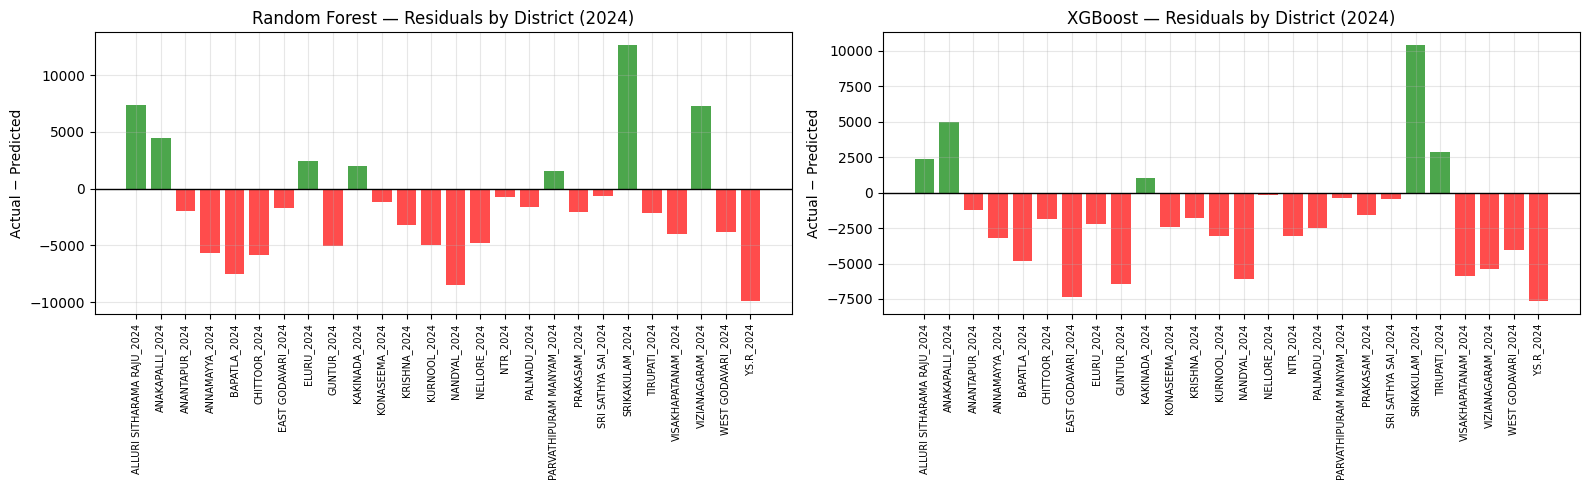

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

residuals_rf  = actual_sorted - pred_rf_sorted
residuals_xgb = actual_sorted - pred_xgb_sorted

# RF residuals
axes[0].bar(range(len(labels_sorted)), residuals_rf, 
            color=['green' if r > 0 else 'red' for r in residuals_rf], alpha=0.7)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Random Forest — Residuals by District (2024)')
axes[0].set_ylabel('Actual − Predicted')
axes[0].set_xticks(range(len(labels_sorted)))
axes[0].set_xticklabels(labels_sorted, rotation=90, fontsize=7)
axes[0].grid(True, alpha=0.3)

# XGBoost residuals
axes[1].bar(range(len(labels_sorted)), residuals_xgb,
            color=['green' if r > 0 else 'red' for r in residuals_xgb], alpha=0.7)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('XGBoost — Residuals by District (2024)')
axes[1].set_ylabel('Actual − Predicted')
axes[1].set_xticks(range(len(labels_sorted)))
axes[1].set_xticklabels(labels_sorted, rotation=90, fontsize=7)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

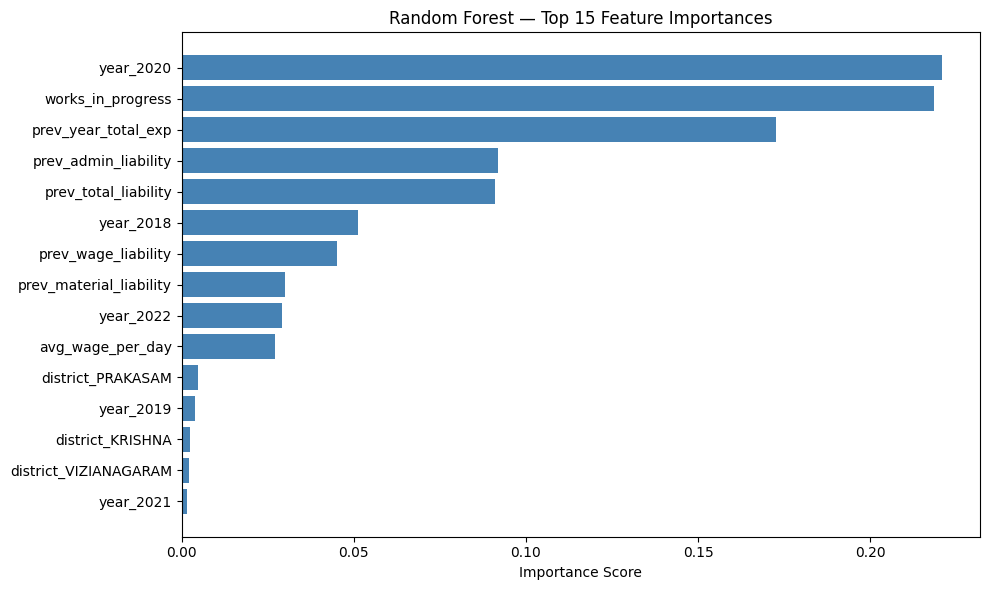

                feature  importance
              year_2020    0.220899
      works_in_progress    0.218654
    prev_year_total_exp    0.172612
   prev_admin_liability    0.091833
   prev_total_liability    0.090909
              year_2018    0.051248
    prev_wage_liability    0.045220
prev_material_liability    0.029906
              year_2022    0.029076
       avg_wage_per_day    0.027022
      district_PRAKASAM    0.004693
              year_2019    0.003775
       district_KRISHNA    0.002369
  district_VIZIANAGARAM    0.002030
              year_2021    0.001522


In [20]:
# Get feature importances from RF
rf_importance = pd.DataFrame({
    'feature': ALL_FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Top 15 features
top15_rf = rf_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top15_rf['feature'][::-1], top15_rf['importance'][::-1], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Random Forest — Top 15 Feature Importances')
plt.tight_layout()
plt.show()

print(top15_rf.to_string(index=False))

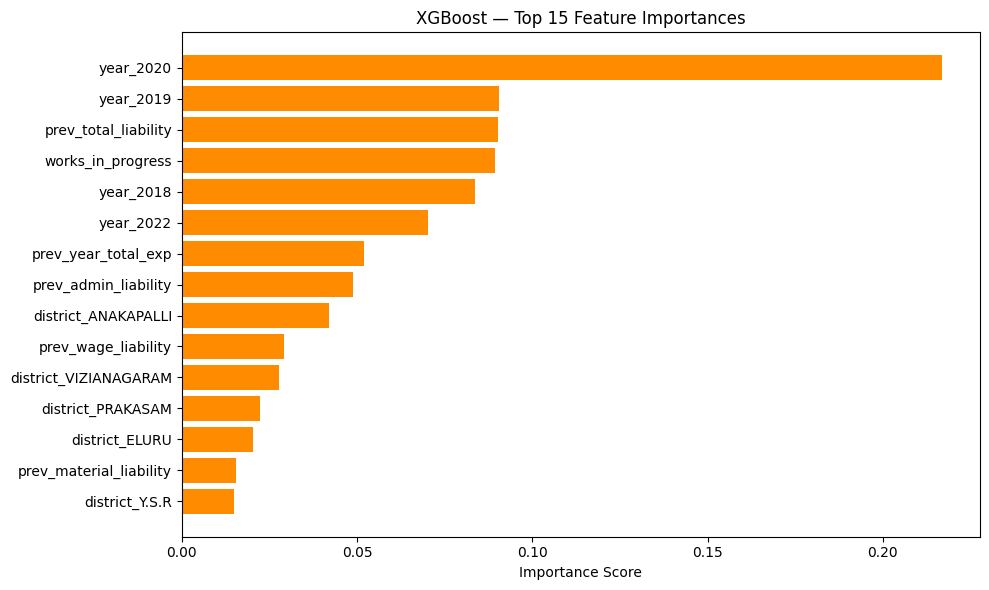

                feature  importance
              year_2020    0.216870
              year_2019    0.090572
   prev_total_liability    0.090228
      works_in_progress    0.089468
              year_2018    0.083541
              year_2022    0.070100
    prev_year_total_exp    0.051992
   prev_admin_liability    0.048712
    district_ANAKAPALLI    0.041929
    prev_wage_liability    0.029235
  district_VIZIANAGARAM    0.027797
      district_PRAKASAM    0.022392
         district_ELURU    0.020307
prev_material_liability    0.015339
         district_Y.S.R    0.014955


In [21]:
xgb_importance = pd.DataFrame({
    'feature': ALL_FEATURES,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

top15_xgb = xgb_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top15_xgb['feature'][::-1], top15_xgb['importance'][::-1], color='darkorange')
plt.xlabel('Importance Score')
plt.title('XGBoost — Top 15 Feature Importances')
plt.tight_layout()
plt.show()

print(top15_xgb.to_string(index=False))